# Exploratory Data Analysis

The objective of this notebook is to perform an Exploratory Data Analysis (EDA) on the dataset used for the project in order to define the necessary/useful preprocessing transformations.

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "tumorgrowth.csv"
EXPORT_PATH = PROJECT_ROOT / "figures"

data = pd.read_csv(DATA_PATH, sep=";")
data.head()

,Grp,Group,ID,Day,Size
0,1.CTR,1,101,0,"41,8"
1,1.CTR,1,101,3,85
2,1.CTR,1,101,4,114
3,1.CTR,1,101,5,"162,3"
4,1.CTR,1,101,6,"178,3"


In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Grp     574 non-null    str  
 1   Group   574 non-null    int64
 2   ID      574 non-null    int64
 3   Day     574 non-null    int64
 4   Size    574 non-null    str  
dtypes: int64(3), str(2)
memory usage: 22.6 KB


In [3]:
data.describe()

,Group,ID,Day
count,574.000000,574.000000,574.000000
mean,2.616725,266.900697,11.364111
std,1.039935,104.296993,7.573364
min,1.000000,101.000000,0.000000
25%,2.000000,203.000000,5.000000
50%,3.000000,302.000000,11.000000
75%,4.000000,401.000000,17.000000
max,4.000000,409.000000,28.000000


## Brief description of the dataset

The dataset contains experimental time-series measurements of tumor volumes from mouse xenograft (human cells were implanted to mice) evaluating four distinct cancer therapies. $n=37$ mice were studied, with base tumor sizes between $40-60mm^3$. The animals were divided into four groups: 1) *Control group* ($n=8$); 2) *Only drug* ($n=10$); 3) *Only radiation* ($n=10$); and 4) *Drug and Radiation* ($n=9$). Tumor size was measured in work days during four weeks, however the number of measures varies among mice because some of them had to be euthanized. The dataset has no missing values.

It seems that the *Size* column in the dataset is stored as a string, however it represents a volume (float). In order to perform the analysis it is necessary to change the data type.

In [4]:
data["Size"] = data["Size"].str.replace(',','.').astype(float)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Grp     574 non-null    str    
 1   Group   574 non-null    int64  
 2   ID      574 non-null    int64  
 3   Day     574 non-null    int64  
 4   Size    574 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 22.6 KB


## Tumor evolution inspection

The first step is to plot raw tumor size evolution w.r.t. time, coloring each individual by its treatment (CTR, D, R or R+D) in order to get and idea of the behavior of the tumor size and propose useful transformations.

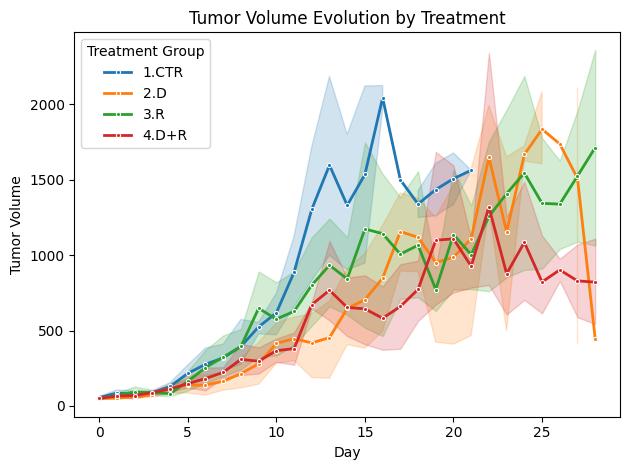

In [5]:
sns.lineplot(
    data=data,
    x="Day",
    y="Size",
    hue="Grp",
    linewidth=2,  
    marker="o",
    markersize=3
)
plt.title("Tumor Volume Evolution by Treatment")
plt.xlabel("Day")
plt.ylabel("Tumor Volume")
plt.legend(title="Treatment Group", loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig(EXPORT_PATH / "fig1.png", dpi=300, bbox_inches="tight")
plt.show()

This graph depicts Tumor Volume Evolution by Treatment. Each line represents the mean tumor volume for all subjects in a treatment group on a given day, while the shaded area exhibits the 95% CI around the mean. As it can be observed, the CI expands as the tumor volume augments (which was expected since large tumors tend to fluctuate more in absolute $\text{mm}^3$). 

This might create an issue with parameter fitting, as high variance typically cause stabilization and identification problems. Nevertheless, no logarithm transformation will be applied to the dataset for the following reasons:

- The structural model describes the evolution of physical cell populations, which operate additively on the actual volume scale.
- Moreover, keeping parameters on the linear scale ensures they retain their original interpretability (e.g., carrying capacity measured directly in $\text{mm}^3$)

In order to overcome the heteroscedasticity issue the errors will be computed on the log scale ( $L = \sum_{i} (\log(V_i) - \log(\hat{V_i}))^2$ ). This operation converts absolute error into relative percentage error, ensuring that a $10$% error when the volume is $100 \text{mm}^3$ carries the same mathematical weight as a $10$% when the volume is $2000 \text{mm}^3$ (see $\log(110) - \log(100) \approx 0.095$ while $\log(2200) - \log(2000) \approx 0.095$). Otherwise the optimizer would prioritize fitting late time points almost exclusively, completely ignoring early growth dynamics.

It might also be useful to plot the evolution of the tumor volume for each mouse, separated in different subplots by treatment.

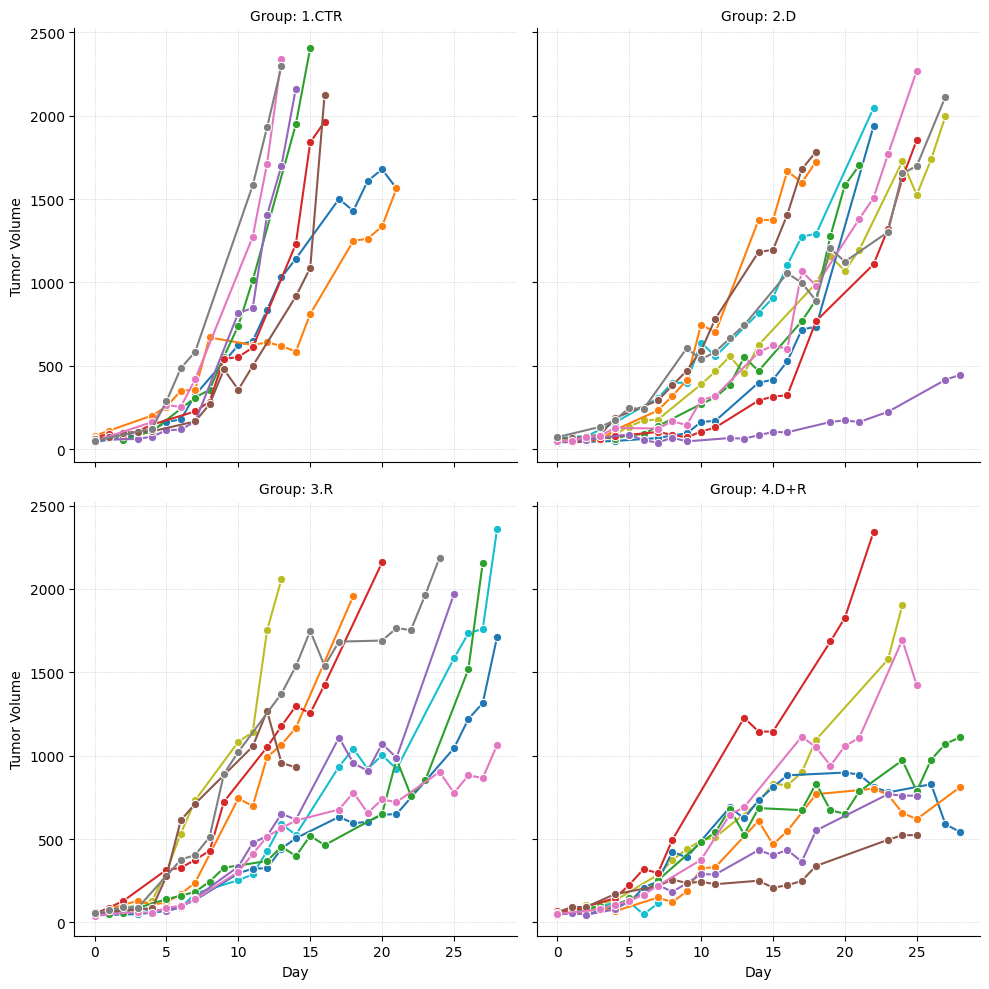

In [6]:
g = sns.relplot(
    data=data,
    x="Day",
    y="Size",
    hue="ID",
    col="Grp",
    kind="line",
    col_wrap=2,
    estimator=None,
    marker="o",
    legend=False,
    palette="tab10"
)

g.set_axis_labels("Day", "Tumor Volume")
g.set_titles(col_template="Group: {col_name}")
for ax in g.axes.flat:
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.8)
plt.savefig(EXPORT_PATH / "fig2.png", dpi=300, bbox_inches="tight")
plt.show()

The following can be observed from the plots:

- The tumor volume of the control group is consistenly the highest and exhibits an aggressive exponential growth. In many of the cases the mice had to be euthanized before the end of the experiment (four weeks) because the tumor had reached an extremelly large size.
- In general it seems that treatment does not stop nor eliminate the tumor, it just reduces the rate of growth. It seems that during the first 10-15 days the different treatments manage to suppress the growth of the tumors, although since then tumor volume augments dramatically for all treated groups. This might indicate acquired treatment resistance among tumor cells.
- Almost all individuals exhibit monotonous growth, however some mice experience slightly erratic tumor volume evolution (which cannot be captured by our model).
- Carrying capacity ($K$) will probably be problematic to identify, since tumors do not reach saturation in any group for the duration of the experiment. The solution to this issue might be to bound $K$ with an educated guess based on tumor literature.
- Mice do not share tumor size baselines (although different baselines are fairly similar). In order to balance the effect/importance of each observation, the model will be fitted using the Relative Tumor Volume (RTV) (computed as $RTV_t = \frac{V_t}{V_0}$) as observations.

## Growth rate evolution inspection

Next it will be analyzed whether tumor growth rates are stable or present high variations for the different treatment groups.

In [7]:
data["delta_Size"] = data.groupby("ID")["Size"].diff()
data["delta_t"] = data.groupby("ID")["Day"].diff()
data["r"] = data["delta_Size"] / data["delta_t"]

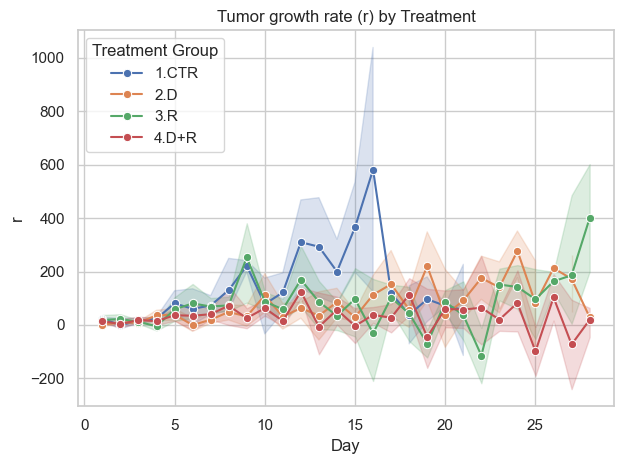

In [8]:
plot_df = data.dropna(subset=["r"]).copy()

sns.set_theme(style="whitegrid")

sns.lineplot(
    data=plot_df,
    x="Day",
    y="r",
    hue="Grp",
    linewidth=1.5,  
    marker="o",
    markersize=6,
)
plt.title("Tumor growth rate (r) by Treatment")
plt.xlabel("Day")
plt.ylabel("r")
plt.legend(title="Treatment Group", loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig(EXPORT_PATH / "fig3.png", dpi=300, bbox_inches="tight")
plt.show()

Although the value seems fairly constant, the plot is altered by the outlier belonging to the control group ($r=600$) and it does tend to increase greatly as time evolves. Moreover, for some treatment groups growth rate becomes negative at various timesteps ($r<0$), which results in a non monotonous volume evolution.

## Limitations

During the EDA it the following limitations regarding the model have been observed:

- Some groups do not exhibit a monotonous behavior, which is not captured by the model used originally. Since the parameters for growth ($r$), max size ($K$) and drug effectiveness ($\alpha$) are locked in as constant numbers the evolution must be monotonous: if drug killing power is higher than growth, the formula forces the tumor size to strictly decrease, however if drug killing power is lower (or zero, in the case of the control group), the formula forces the tumor size to strictly augment. 
- The assumption of a constant $r$ might not be feasible for this dataset, since it increases and varies significantly during the experiment for all groups. 

## Solution

In order to overcome the stiff assumptions needed (which the data does not seem to follow), the initial model will be expanded by incorporating tumor cell resistance. It has been observed that during the first days the treatments managed to control tumor growth, however after sufficient time had passed all treated groups experienced a sharp growth in tumor volume. This is probably due to the fact that some tumor cells develop resistance to the treatment.

The new proposed model solves this issue by tracking two distinct cell sub-populations simultaneously: a drug-sensitive population ($T_s$) and a drug-resistant population ($T_r$).

$$T_{s,t+1}=T_{s,t} + r_s · T_{s,t}(1 - \frac{T_{s,t} + T_{r,t}}{K}) - \alpha · D_t · T_{s,t} - \mu · T_{s,t}$$
$$T_{r,t+1}=T_{r,t} + r_r · T_{r,t}(1 - \frac{T_{s,t} + T_{r,t}}{K}) + \mu · T_{s,t}$$

Where:

- $T_s$ and $T_r$ are volumes of sensitive and resistant cells.
- $r_s$ and $r_r$ are growth rates for sensitive and resistant rates.
- $K$ is total carrying capacity.
- $\alpha · D(t)$ responds to drug killing efficiency (applied only to the sensitive cells).
- $\mu$ is the mutation rate from sensitive to resistant phenotype.

Therefore, $V_t = T_{s,t} + T_{r,t}$.

Regarding the value of $D(t)$, since the actual dose is not know this value will be treated as a binary indicator of when treatment is applied and when it is not. Therefore, the $\alpha$ parameter can be interpreted as *cellular death rate caused by treatment*.

Finally, the original model will not be completely discarded, as it will serve as a benchmark for the advanced model. 

## Preprocessing

Taking all the above into consideration, the preprocessing will consist on adjusting the *Size* column type and adding the $RTV$ column to the dataset, since there are no significant outliers nor missing values and the logarithm transformation has been discarded.